# Trained PatchCore ViT Evaluation (70k Normal / 3.5k Defect)

This notebook loads a saved trained PatchCore ViT artifact and evaluates it on an exact test set of:
- 70,000 normal wafers
- 3,500 defect wafers

No model training is performed here; this is artifact-only evaluation.

In [1]:
import importlib, subprocess, sys
for pkg in ['timm', 'tqdm']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencies ready')

Dependencies ready


In [2]:
import os
import gc
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Device:', DEVICE)

C:\Users\kyler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
# Configuration
DATA_PATH = '../../data/raw/LSWMD.pkl'
ARTIFACT_PATH = '../artifacts/trained_patchcore/patchcore_trained_model.pt'
METRICS_OUT = '../artifacts/trained_patchcore/evaluation_metrics_70k_3p5k.json'
SCORES_OUT = '../artifacts/trained_patchcore/scores_70k_3p5k.npz'

IMAGE_SIZE = 224
EVAL_NORMAL_N = 70_000
EVAL_DEFECT_N = 3_500

BATCH_SIZE = 128 if USE_CUDA else 64
NUM_WORKERS = 0
PIN_MEMORY = USE_CUDA

SCORE_CHUNK = 512
PATCHCORE_NN_K = 3
TOPK_PATCH_RATIO = 0.10

print('Artifact path:', ARTIFACT_PATH)
print('Eval target -> normal:', EVAL_NORMAL_N, '| defect:', EVAL_DEFECT_N)

Artifact path: ../artifacts/trained_patchcore/patchcore_trained_model.pt
Eval target -> normal: 70000 | defect: 3500


In [4]:
# Load and clean WM-811K labels
df = pd.read_pickle(DATA_PATH)

def parse_failure_label(v):
    if v is None:
        return 'unknown'
    if isinstance(v, float) and np.isnan(v):
        return 'unknown'
    if isinstance(v, (list, tuple, np.ndarray)):
        a = np.array(v).reshape(-1)
        return 'unknown' if len(a) == 0 else str(a[0])
    return str(v)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

if len(normal_df) < EVAL_NORMAL_N:
    raise ValueError(f'Need {EVAL_NORMAL_N:,} normals, have {len(normal_df):,}')
if len(defect_df) < EVAL_DEFECT_N:
    raise ValueError(f'Need {EVAL_DEFECT_N:,} defects, have {len(defect_df):,}')

eval_normal_df = normal_df.sample(n=EVAL_NORMAL_N, random_state=SEED).reset_index(drop=True)
eval_defect_df = defect_df.sample(n=EVAL_DEFECT_N, random_state=SEED).reset_index(drop=True)

print(f'Labeled total: {len(df):,}')
print(f'Normal pool : {len(normal_df):,} -> eval {len(eval_normal_df):,}')
print(f'Defect pool : {len(defect_df):,} -> eval {len(eval_defect_df):,}')

Labeled total: 172,950
Normal pool : 147,431 -> eval 70,000
Defect pool : 25,519 -> eval 3,500


In [5]:
# Dataset + model loader from saved artifact
class BaseWaferDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, size: int = 224):
        self.maps = frame['waferMap'].values
        self.labels = frame['is_anomaly'].values.astype(np.int64)
        self.size = size

    def __len__(self):
        return len(self.maps)

    def __getitem__(self, idx):
        arr = np.clip(np.array(self.maps[idx], dtype=np.int64), 0, 2)
        x = torch.tensor(arr, dtype=torch.long)
        x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
        x = F.interpolate(x.unsqueeze(0), size=(self.size, self.size), mode='nearest').squeeze(0)
        return x, int(self.labels[idx])

class FineTunedPatchExtractor(nn.Module):
    def __init__(self, vit: nn.Module, block_idx: int, proj_dim: int):
        super().__init__()
        self.vit = vit
        self._feat = None
        self.vit.blocks[block_idx].register_forward_hook(
            lambda m, i, o: setattr(self, '_feat', o)
        )
        self.proj = nn.Linear(self.vit.embed_dim, proj_dim, bias=False)

    def forward(self, x):
        self.vit(x)
        return self._feat[:, 1:, :]

if not os.path.exists(ARTIFACT_PATH):
    raise FileNotFoundError(f'Artifact not found: {ARTIFACT_PATH}')

ckpt = torch.load(ARTIFACT_PATH, map_location='cpu')
memory_bank = ckpt['memory_bank'].to(DEVICE)
memory_bank = F.normalize(memory_bank.float(), p=2, dim=1)
best_thresh = float(ckpt['threshold'])
vit_block = int(ckpt.get('vit_block', 6))
proj_dim = int(ckpt.get('proj_dim', 128))

backbone = timm.create_model('vit_base_patch16_224.augreg_in21k_ft_in1k', pretrained=False, num_classes=0)
extractor = FineTunedPatchExtractor(backbone, block_idx=vit_block, proj_dim=proj_dim).to(DEVICE).eval()
extractor.load_state_dict(ckpt['extractor_state'], strict=True)
for p in extractor.parameters():
    p.requires_grad = False

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
normal_loader = DataLoader(BaseWaferDataset(eval_normal_df, IMAGE_SIZE), **loader_kwargs)
defect_loader = DataLoader(BaseWaferDataset(eval_defect_df, IMAGE_SIZE), **loader_kwargs)

print(f'Threshold from artifact: {best_thresh:.6f}')
print(f'Memory bank shape      : {tuple(memory_bank.shape)}')
print(f'Extractor block/proj   : block={vit_block}, proj_dim={proj_dim}')

Threshold from artifact: 0.613502
Memory bank shape      : (600000, 128)
Extractor block/proj   : block=6, proj_dim=128


In [6]:
@torch.inference_mode()
def extract_embeddings(xb: torch.Tensor) -> torch.Tensor:
    with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
        feat = extractor(xb)
        emb = extractor.proj(feat)
    emb = emb.float().reshape(-1, emb.shape[-1])
    emb = F.normalize(emb, p=2, dim=1)
    return emb

@torch.inference_mode()
def score_loader(loader: DataLoader):
    scores, labels = [], []
    for xb, yb in tqdm(loader, desc='Scoring', leave=False):
        xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        emb = extract_embeddings(xb)

        B = len(xb)
        P = emb.shape[0] // B
        patch_dists = torch.empty(B * P, dtype=torch.float32, device=DEVICE)

        for start in range(0, B * P, SCORE_CHUNK):
            end = min(start + SCORE_CHUNK, B * P)
            chunk = emb[start:end]
            dists = torch.cdist(chunk, memory_bank)
            knn = dists.topk(PATCHCORE_NN_K, dim=1, largest=False).values
            patch_dists[start:end] = knn.mean(dim=1)

        patch_dists = patch_dists.view(B, P)
        topk = max(1, int(P * TOPK_PATCH_RATIO))
        img_scores = patch_dists.topk(topk, dim=1).values.mean(dim=1)

        scores.extend(img_scores.cpu().tolist())
        labels.extend(yb.numpy().tolist())

    return np.array(scores), np.array(labels)

print('Scoring normal set...')
normal_scores, normal_labels = score_loader(normal_loader)

print('Scoring defect set...')
defect_scores, defect_labels = score_loader(defect_loader)

all_scores = np.concatenate([normal_scores, defect_scores])
all_labels = np.concatenate([normal_labels, defect_labels])
pred = (all_scores > best_thresh).astype(int)

roc_auc = roc_auc_score(all_labels, all_scores)
auprc = average_precision_score(all_labels, all_scores)
cm = confusion_matrix(all_labels, pred)

print('\nOverall results (70k normal + 3.5k defect)')
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'AUPRC   : {auprc:.4f}')
print(f'Threshold: {best_thresh:.6f}')
print()
print(classification_report(all_labels, pred, target_names=['Normal', 'Defect'], digits=4))

Scoring normal set...


Scoring defect set...



Overall results (70k normal + 3.5k defect)
ROC-AUC : 0.9581
AUPRC   : 0.7235
Threshold: 0.613502

              precision    recall  f1-score   support

      Normal     0.9901    0.9522    0.9707     70000
      Defect     0.4582    0.8091    0.5851      3500

    accuracy                         0.9453     73500
   macro avg     0.7241    0.8806    0.7779     73500
weighted avg     0.9647    0.9453    0.9524     73500



Overall defect recall: 80.91%


,failure_label,count,detected,recall,mean_score,median_score
0,Scratch,158,94,0.594937,0.679202,0.639751
1,Edge-Loc,723,479,0.662517,0.659188,0.645689
2,Loc,488,349,0.715164,0.659511,0.648097
3,Center,547,392,0.716636,0.654392,0.642349
4,Edge-Ring,1364,1298,0.951613,0.684251,0.685278
5,Near-full,17,17,1.000000,0.796213,0.793035
6,Random,125,125,1.000000,0.770452,0.772821
7,Donut,78,78,1.000000,0.760070,0.766957


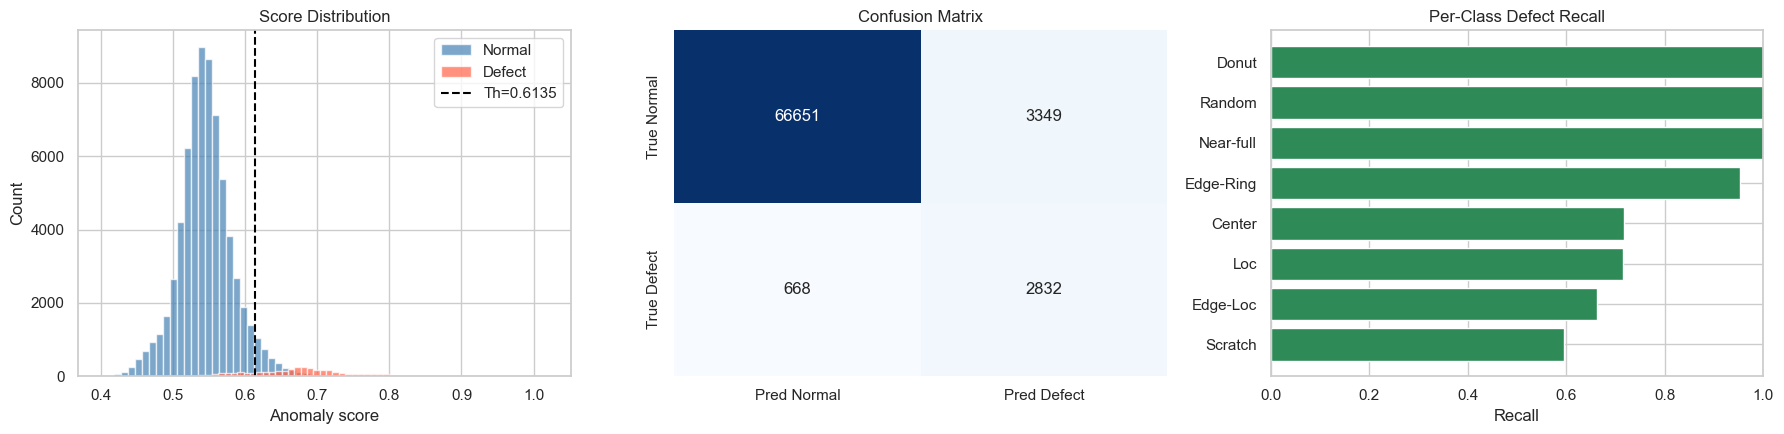

In [7]:
# Per-class defect recall
defect_pred = (defect_scores > best_thresh).astype(int)
defect_classes = eval_defect_df['failure_label'].values

rows = []
for cls in sorted(np.unique(defect_classes)):
    m = defect_classes == cls
    n = int(m.sum())
    detected = int(defect_pred[m].sum())
    recall = float(detected / max(1, n))
    rows.append({
        'failure_label': cls,
        'count': n,
        'detected': detected,
        'recall': recall,
        'mean_score': float(defect_scores[m].mean()),
        'median_score': float(np.median(defect_scores[m])),
    })

per_class_df = pd.DataFrame(rows).sort_values(['recall', 'mean_score'], ascending=[True, False]).reset_index(drop=True)
overall_defect_recall = float(defect_pred.mean())

print(f'Overall defect recall: {overall_defect_recall:.2%}')
display(per_class_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(normal_scores, bins=60, alpha=0.7, label='Normal', color='steelblue')
axes[0].hist(defect_scores, bins=60, alpha=0.7, label='Defect', color='tomato')
axes[0].axvline(best_thresh, color='black', linestyle='--', label=f'Th={best_thresh:.4f}')
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Anomaly score')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Normal', 'Pred Defect'],
            yticklabels=['True Normal', 'True Defect'], ax=axes[1])
axes[1].set_title('Confusion Matrix')

plot_df = per_class_df.sort_values('recall', ascending=True)
axes[2].barh(plot_df['failure_label'], plot_df['recall'], color='seagreen')
axes[2].set_xlim(0, 1)
axes[2].set_xlabel('Recall')
axes[2].set_title('Per-Class Defect Recall')

plt.tight_layout()
plt.show()

F1 sweep on evaluation set
Best F1        : 0.6967
Best threshold : 0.649667
Precision      : 0.7306
Recall         : 0.6657

Confusion matrix at best F1 threshold:
[[69141   859]
 [ 1170  2330]]

              precision    recall  f1-score   support

      Normal     0.9834    0.9877    0.9855     70000
      Defect     0.7306    0.6657    0.6967      3500

    accuracy                         0.9724     73500
   macro avg     0.8570    0.8267    0.8411     73500
weighted avg     0.9713    0.9724    0.9718     73500



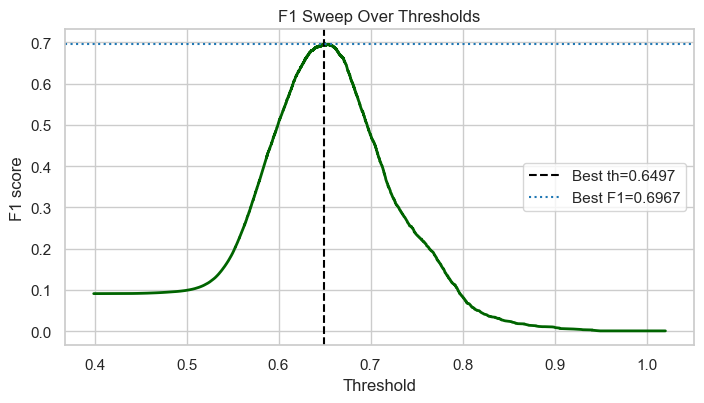

In [9]:
# F1 threshold sweep on the held-out evaluation set
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(all_labels, all_scores)
if len(thresholds) == 0:
    raise ValueError('Not enough score variation to compute an F1 sweep.')

f1_values = (2 * precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
best_idx = int(np.argmax(f1_values))
best_f1_threshold = float(thresholds[best_idx])
best_f1 = float(f1_values[best_idx])
best_precision = float(precision[best_idx])
best_recall = float(recall[best_idx])

sweep_pred = (all_scores >= best_f1_threshold).astype(int)
sweep_cm = confusion_matrix(all_labels, sweep_pred)

print('F1 sweep on evaluation set')
print(f'Best F1        : {best_f1:.4f}')
print(f'Best threshold : {best_f1_threshold:.6f}')
print(f'Precision      : {best_precision:.4f}')
print(f'Recall         : {best_recall:.4f}')
print()
print('Confusion matrix at best F1 threshold:')
print(sweep_cm)
print()
print(classification_report(all_labels, sweep_pred, target_names=['Normal', 'Defect'], digits=4))

plt.figure(figsize=(7.2, 4.2))
plt.plot(thresholds, f1_values, color='darkgreen', linewidth=2)
plt.axvline(best_f1_threshold, color='black', linestyle='--', label=f'Best th={best_f1_threshold:.4f}')
plt.axhline(best_f1, color='tab:blue', linestyle=':', label=f'Best F1={best_f1:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('F1 Sweep Over Thresholds')
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# Save metrics and scores
out_dir = os.path.dirname(METRICS_OUT)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

metrics = {
    'artifact_path': ARTIFACT_PATH,
    'data_path': DATA_PATH,
    'image_size': IMAGE_SIZE,
    'eval_normal_n': int(EVAL_NORMAL_N),
    'eval_defect_n': int(EVAL_DEFECT_N),
    'threshold': float(best_thresh),
    'roc_auc': float(roc_auc),
    'auprc': float(auprc),
    'overall_defect_recall': float(overall_defect_recall),
    'confusion_matrix': cm.tolist(),
    'per_class': per_class_df.to_dict(orient='records'),
}

with open(METRICS_OUT, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

np.savez(
    SCORES_OUT,
    normal_scores=normal_scores,
    defect_scores=defect_scores,
    threshold=np.array([best_thresh], dtype=np.float32),
)

print('Saved metrics:', METRICS_OUT)
print('Saved scores :', SCORES_OUT)

Saved metrics: ../artifacts/trained_patchcore/evaluation_metrics_70k_3p5k.json
Saved scores : ../artifacts/trained_patchcore/scores_70k_3p5k.npz
